# 04 — Hierarchical Clustering with Kernel Distances

**Vignette index:** | [`01` GKMKernel basics](01_basic_kernel_matrix.ipynb) | [`02` Distance metrics & kernels](02_distance_metrics_and_kernels.ipynb) | [`03` SVM with kernel](03_svc_with_kernel.ipynb) | `**04**` Clustering | [`05` Long sequence scoring](05_score_long_sequence.ipynb) | [`06` Weighted (WGKM) kernel](06_weighted_kernel.ipynb) | [`07` Transforms & comparison](07_transform_and_comparison.ipynb) | [`08` Windowed 3D tensors](08_windowed_3d_tensors.ipynb) | [`09` Spectrum encoder & NB](09_spectrum_encoder_and_differential.ipynb) | [`10` Gappy encoder](10_gappy_encoder.ipynb) | [`11` Mismatch encoder](11_mismatch_encoder.ipynb) | [`12` Shuffler & chunker](12_shuffler_and_chunker.ipynb)

Use a gkm kernel to compute pairwise distances and cluster sequences hierarchically.

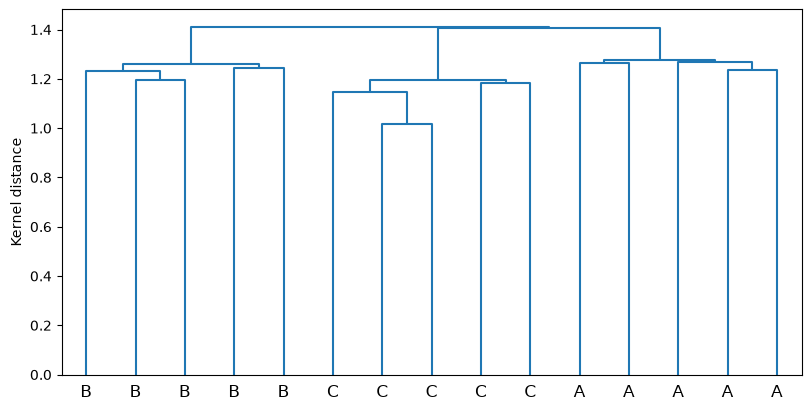

In [1]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from kmer.kernels import GKMKernel

np.random.seed(0)
def random_seq(n, rng):
    return "".join(rng.choice(list("ACGT"), size=n))
rng = np.random.default_rng(0)
group_a = ["ACGTACGT" + random_seq(12, rng) for _ in range(5)]
group_b = ["TTTTAAAA" + random_seq(12, rng) for _ in range(5)]
group_c = ["GCGCGCGC" + random_seq(12, rng) for _ in range(5)]
seqs = group_a + group_b + group_c
labels = ["A"]*5 + ["B"]*5 + ["C"]*5

kern = GKMKernel(L=8, k=5, d=2, kernel_type="truncated", use_rc=True)
kern.set_references(seqs)
K = np.asarray(kern.kernel())

# Distance: d = sqrt(2 - 2*K(a,b)) since diagonal is 1.0
D = np.sqrt(np.maximum(2 - 2*K, 0))
np.fill_diagonal(D, 0)
D = (D + D.T) / 2

condensed = squareform(D, checks=False)
Z = linkage(condensed, method="average")

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
dendrogram(Z, labels=labels, ax=ax)
ax.set_ylabel("Kernel distance")
plt.show()